In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix

In [2]:
df = pd.read_csv("../files/early_diabetes_data_cleaned.csv")

target = df['class']
features = df.drop('class', axis = 1).copy()

In [42]:
min_val = np.min(df['Age'].astype(int))
max_val = np.max(df['Age'].astype(int))

n_bins = 5
bins = np.linspace(min_val, max_val, n_bins + 1)
bins = np.round(bins).astype(int)

bins = np.unique(bins)
bin_labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]
df["Age group"] = pd.cut(df['Age'], bins=bins, labels=bin_labels, include_lowest=True)

labels = ['Age group', 'class']
sliced = df.loc[:,labels]

new_labels = ['Age group', 'Positive', 'Negative']

diabetes_per_df = sliced.groupby('Age group').mean().reset_index()
diabetes_per_df['Negative'] = 1 - diabetes_per_df['class']
diabetes_per_df.columns = new_labels

df['Age group'].value_counts()

Age group
46-60    201
31-46    191
60-75     75
16-31     48
75-90      5
Name: count, dtype: int64

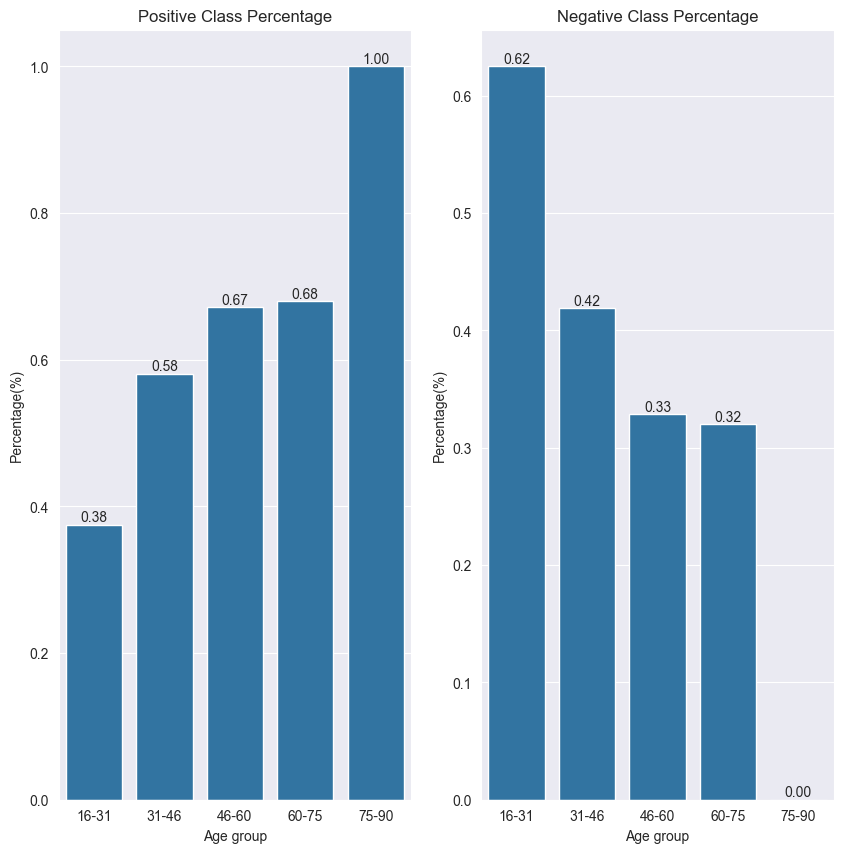

In [4]:
fig, axs = plt.subplots(1,2,figsize=(10,10))

for idx, ax in enumerate(axs.flat):
    occur = ['Positive', 'Negative']

    sns.barplot(data=diabetes_per_df, x = 'Age group', y = occur[idx], ax=ax)
    ax.set_ylabel('Percentage(%)')
    ax.set_title(f'{occur[idx]} Class Percentage')

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f')

# Percentage of the Positive Physiological Factors among all Diabetes Class

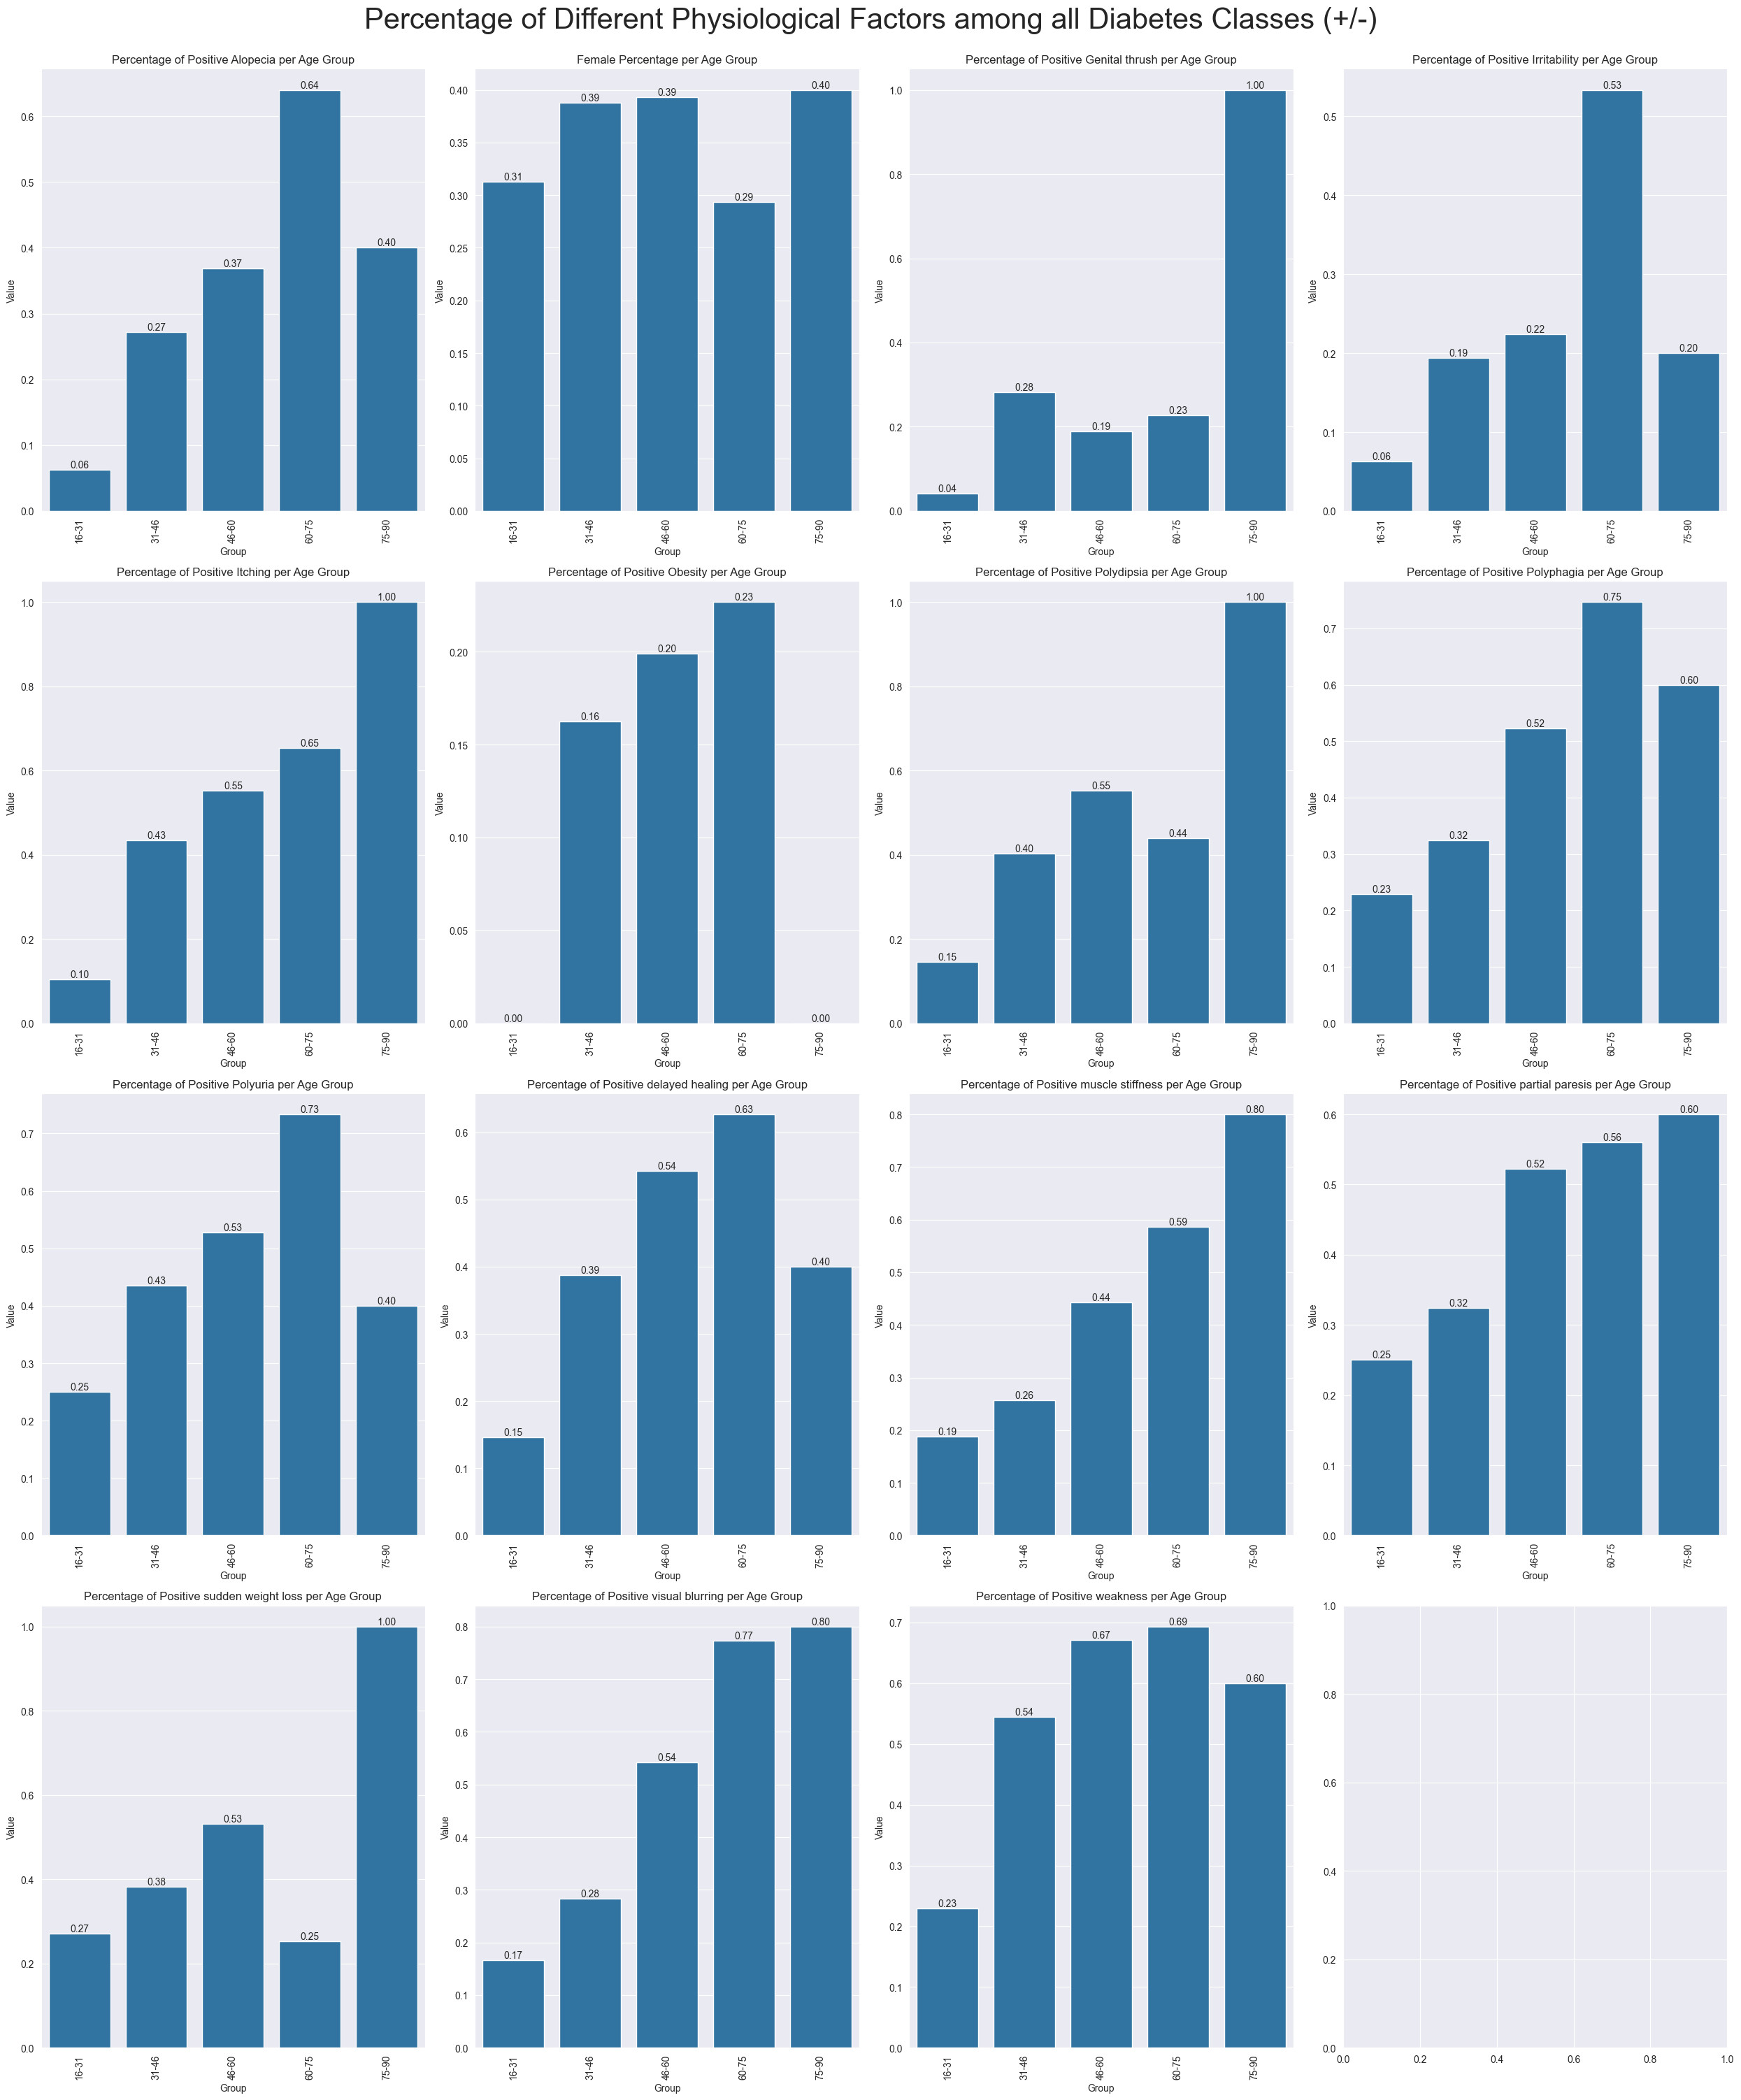

In [29]:
binned_mean = np.transpose(df.groupby('Age group').mean().drop('Age', axis=1))
bin_group = binned_mean.columns
cols = pd.concat([pd.Series(['Factor']), pd.Series(binned_mean.columns)])
binned_mean.reset_index(inplace=True)
binned_mean.columns = cols

combined = binned_mean.melt(
    id_vars="Factor",
    value_vars=bin_group,
    var_name="Group",
    value_name="Value"
)

fig, axs = plt.subplots(4, 4, figsize=(25,30))
factors = np.unique(combined['Factor'])

mask = factors != 'class'
factors = factors[mask]

for idx, ax in enumerate(axs.flat):
    if idx != factors.size:
        factor = factors[idx]
        factor_df = combined[combined['Factor'] == factor]

        sns.barplot(data=factor_df, y = 'Value',x = 'Group', ax=ax)

        if factor == 'Gender':
            ax.set_title(f"Female Percentage per Age Group")
        else:
            ax.set_title(f"Percentage of Positive {factor} per Age Group")
        ax.tick_params(axis='x', rotation=90)

        for container in ax.containers:
            ax.bar_label(container, fmt="%.2f")


fig.suptitle('Percentage of Different Physiological Factors among all Diabetes Classes (+/-)', y = 1, fontsize=30)
plt.tight_layout()
plt.show()

# Percentage of the Positive Physiological Factors among Positive Diabetes Class

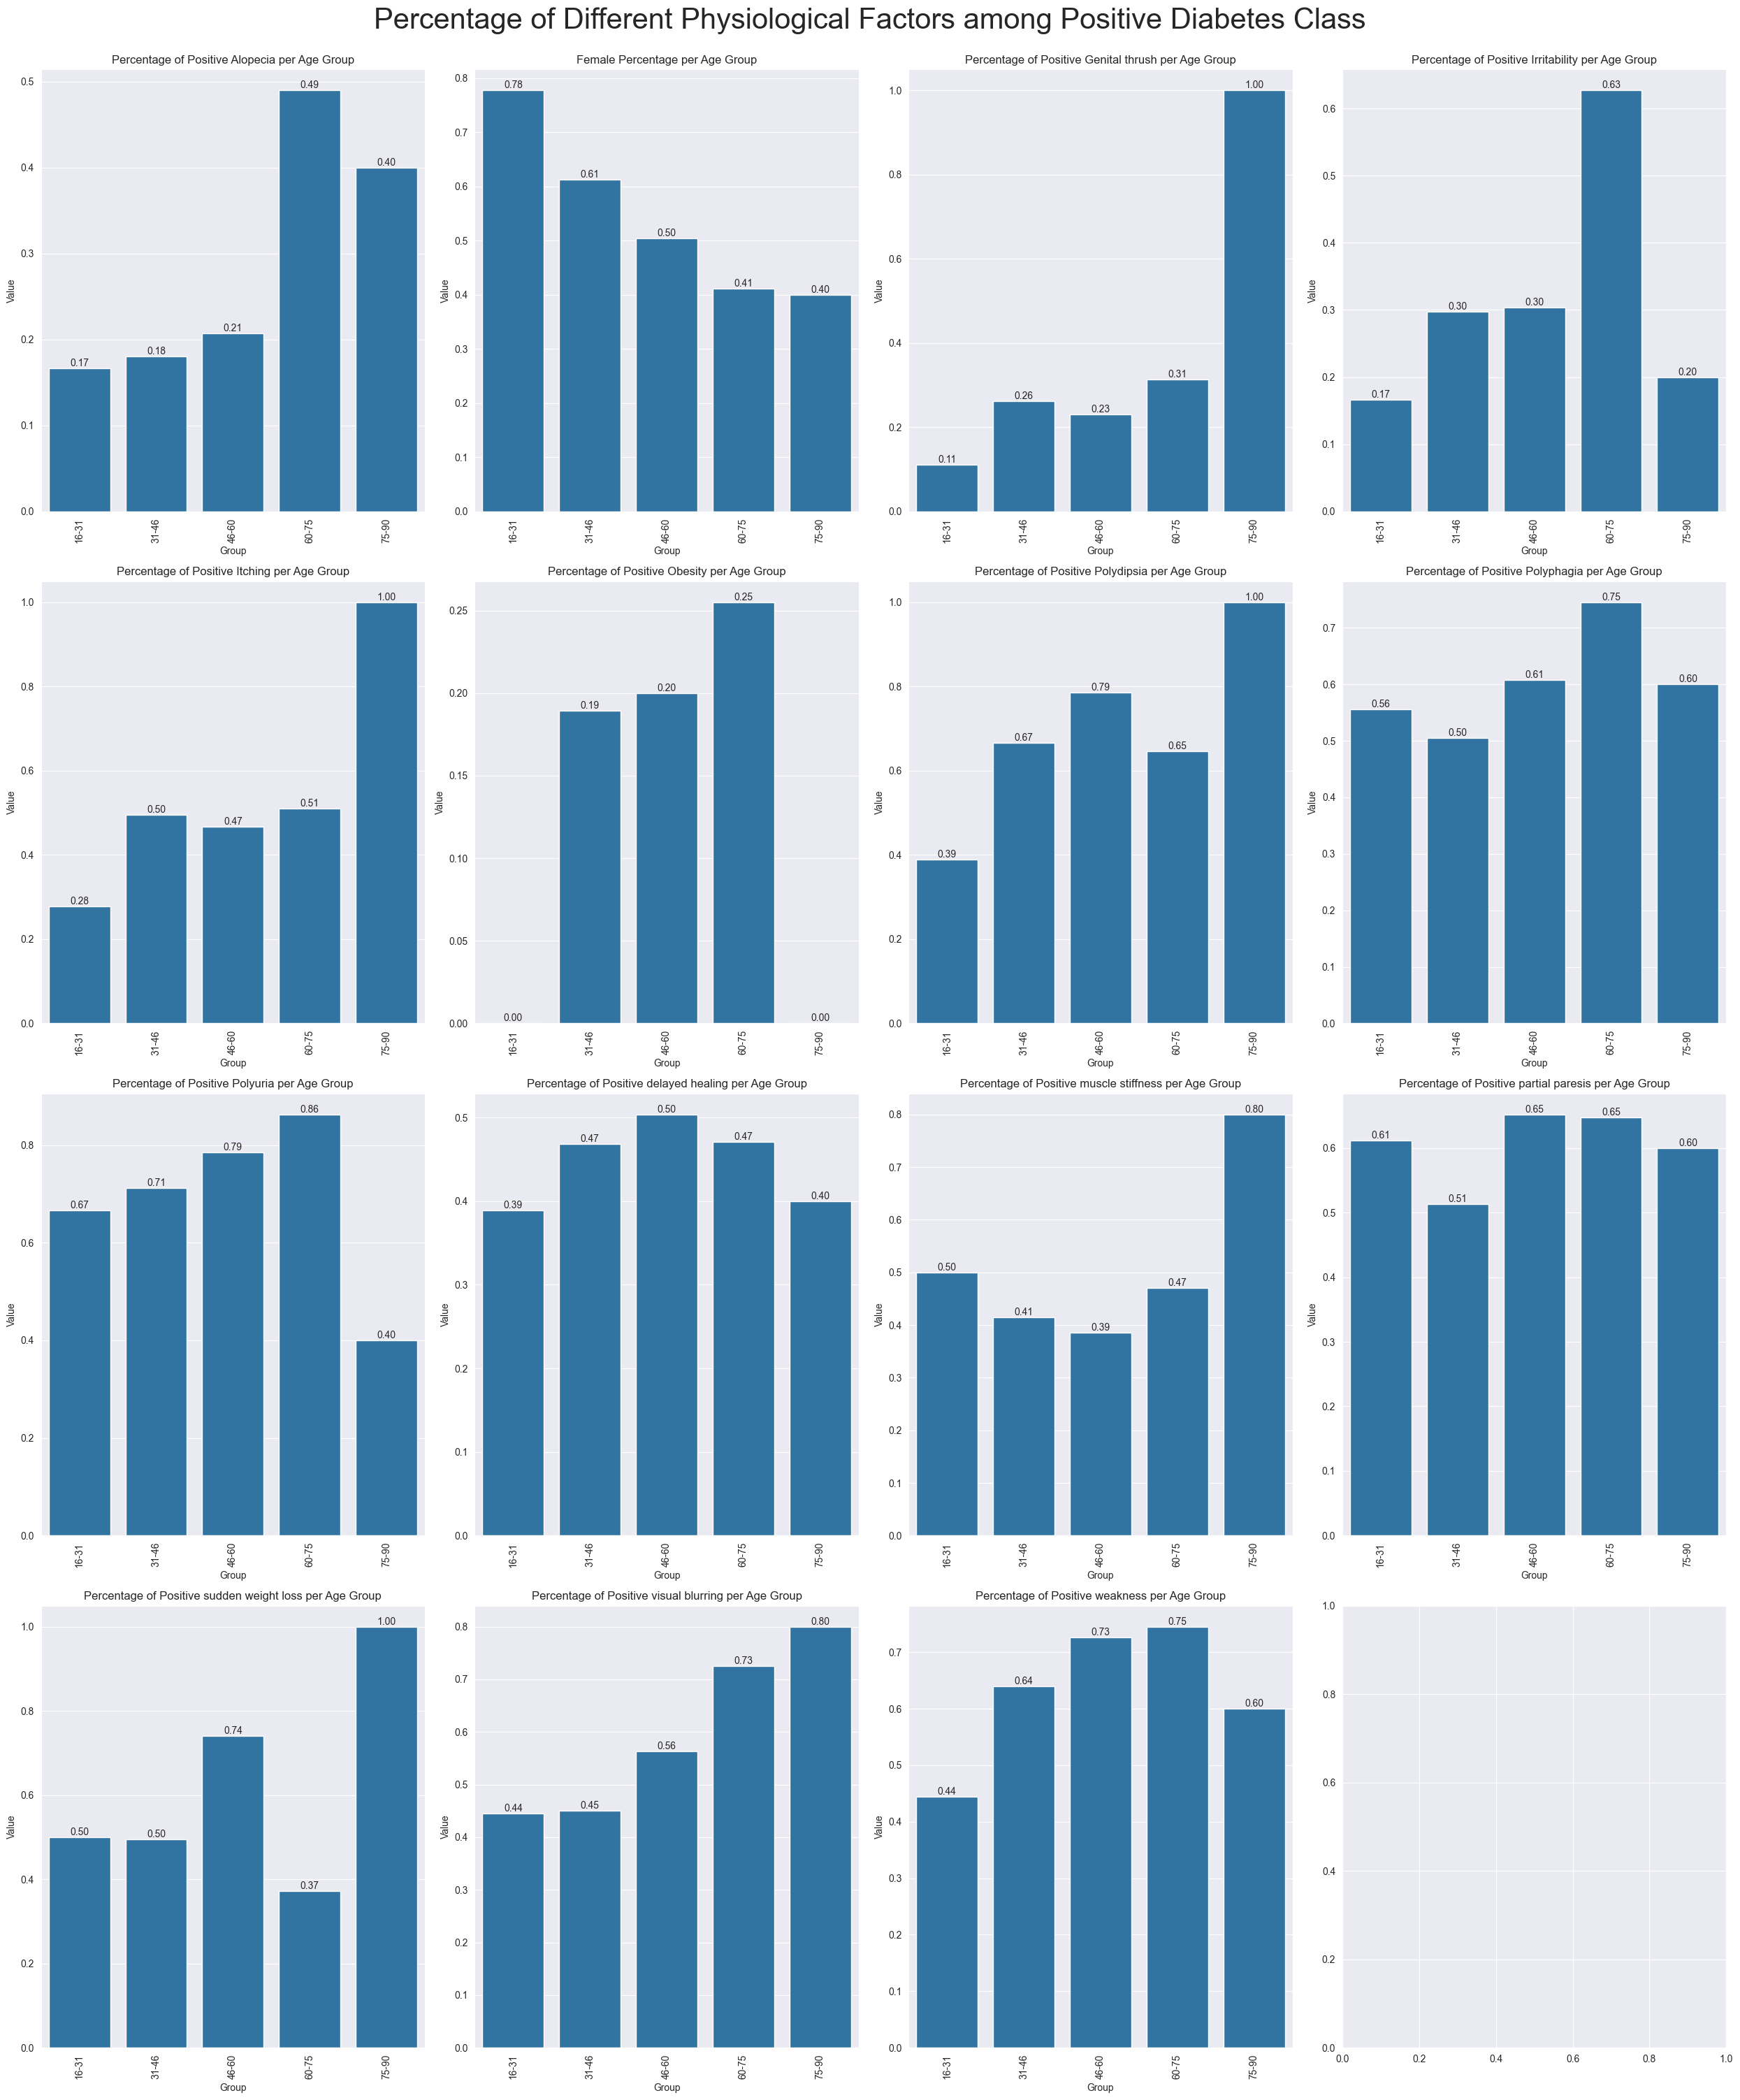

In [30]:
positive_class = df[df['class'] == 1]
binned_mean = np.transpose(positive_class.groupby('Age group').mean().drop('Age', axis=1))
bin_group = binned_mean.columns
cols = pd.concat([pd.Series(['Factor']), pd.Series(binned_mean.columns)])
binned_mean.reset_index(inplace=True)
binned_mean.columns = cols

combined = binned_mean.melt(
    id_vars="Factor",
    value_vars=bin_group,
    var_name="Group",
    value_name="Value"
)

fig, axs = plt.subplots(4, 4, figsize=(25,30))
factors = np.unique(combined['Factor'])

mask = factors != 'class'
factors = factors[mask]

for idx, ax in enumerate(axs.flat):
    if idx != factors.size:
        factor = factors[idx]
        factor_df = combined[combined['Factor'] == factor]

        sns.barplot(data=factor_df, y = 'Value',x = 'Group', ax=ax)

        if factor == 'Gender':
            ax.set_title(f"Female Percentage per Age Group")
        elif factor == 'class':
            ax.set_title(f"Positive Diabetes Percentage per Age Group")
        else:
            ax.set_title(f"Percentage of Positive {factor} per Age Group")
        ax.tick_params(axis='x', rotation=90)

        for container in ax.containers:
            ax.bar_label(container, fmt="%.2f")


fig.suptitle('Percentage of Different Physiological Factors among Positive Diabetes Class', y = 1, fontsize=30)
plt.tight_layout()
plt.show()

# Percentage of the Positive Physiological Factors among Negative Diabetes Class

In [43]:
positive_class = df[df['class'] == 0]
binned_mean = np.transpose(positive_class.groupby('Age group').mean().drop('Age', axis=1))
bin_group = binned_mean.columns
cols = pd.concat([pd.Series(['Factor']), pd.Series(binned_mean.columns)])
binned_mean.reset_index(inplace=True)
binned_mean.columns = cols

binned_mean

,Factor,16-31,31-46,46-60,60-75
0,Gender,0.033333,0.0750,0.166667,0.041667
1,Polyuria,0.000000,0.0500,0.000000,0.458333
2,Polydipsia,0.000000,0.0375,0.075758,0.000000
3,sudden weight loss,0.133333,0.2250,0.106061,0.000000
4,weakness,0.100000,0.4125,0.560606,0.583333
5,Polyphagia,0.033333,0.0750,0.348485,0.750000
6,Genital thrush,0.000000,0.3125,0.106061,0.041667
7,visual blurring,0.000000,0.0500,0.500000,0.875000
8,Itching,0.000000,0.3500,0.727273,0.958333
9,Irritability,0.000000,0.0500,0.060606,0.333333


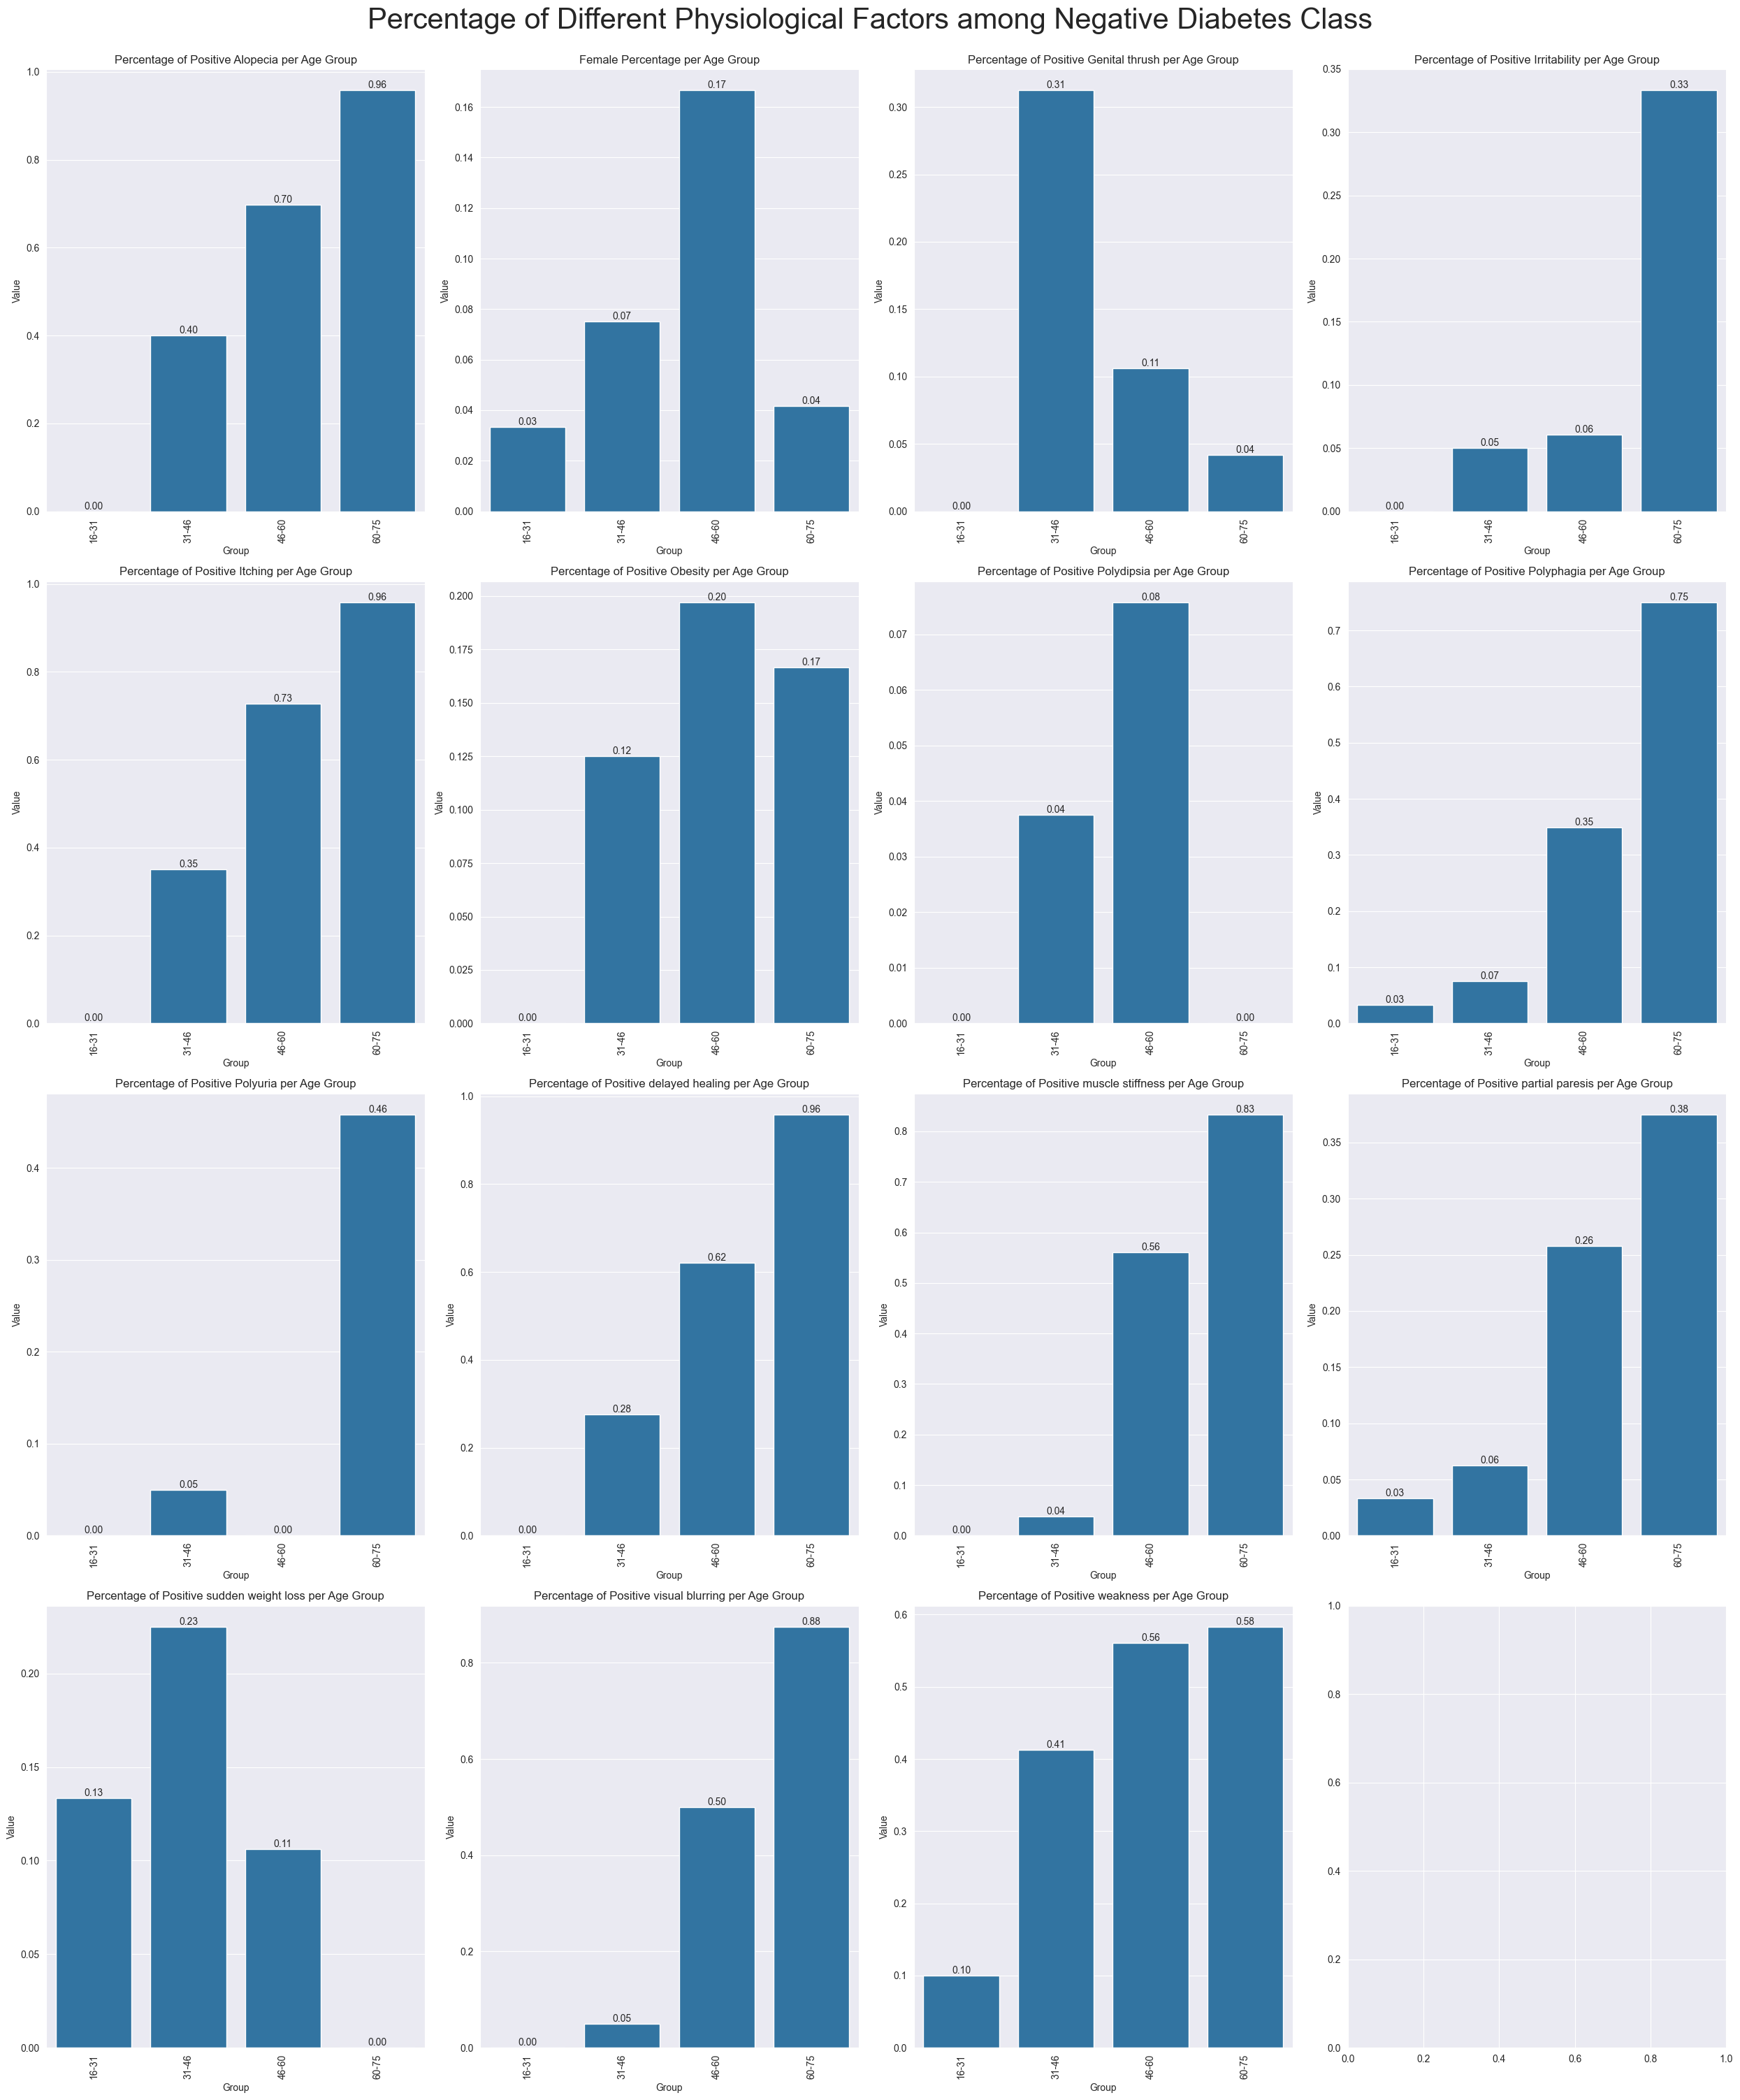

In [31]:
positive_class = df[df['class'] == 0]
binned_mean = np.transpose(positive_class.groupby('Age group').mean().drop('Age', axis=1))
bin_group = binned_mean.columns
cols = pd.concat([pd.Series(['Factor']), pd.Series(binned_mean.columns)])
binned_mean.reset_index(inplace=True)
binned_mean.columns = cols

combined = binned_mean.melt(
    id_vars="Factor",
    value_vars=bin_group,
    var_name="Group",
    value_name="Value"
)

fig, axs = plt.subplots(4, 4, figsize=(25,30))
factors = np.unique(combined['Factor'])

mask = factors != 'class'
factors = factors[mask]

for idx, ax in enumerate(axs.flat):
    if idx != factors.size:
        factor = factors[idx]
        factor_df = combined[combined['Factor'] == factor]

        sns.barplot(data=factor_df, y = 'Value',x = 'Group', ax=ax)

        if factor == 'Gender':
            ax.set_title(f"Female Percentage per Age Group")
        elif factor == 'class':
            ax.set_title(f"Positive Diabetes Percentage per Age Group")
        else:
            ax.set_title(f"Percentage of Positive {factor} per Age Group")
        ax.tick_params(axis='x', rotation=90)

        for container in ax.containers:
            ax.bar_label(container, fmt="%.2f")


fig.suptitle('Percentage of Different Physiological Factors among Negative Diabetes Class', y = 1, fontsize=30)
plt.tight_layout()
plt.show()

In [ ]:
age_bins = pd.qcut(
    df["Age"],
    q=4,
    labels=["Q1 (Youngest)", "Q2", "Q3", "Q4 (Oldest)"]
)

df["Age group"] = pd.qcut(
    df["Age"],
    q=4,
    labels=["Q1 (Youngest)", "Q2", "Q3", "Q4 (Oldest)"]
)

labels = ['Age group', 'class']
sliced = df.loc[:, labels]

new_labels = ['Age group', 'Positive', 'Negative']

diabetes_per_df = sliced.groupby('Age group').mean().reset_index()
diabetes_per_df['Negative'] = 1 - diabetes_per_df['class']
diabetes_per_df.columns = new_labels

fig, axs = plt.subplots(1,2,figsize=(10,5))

for idx, ax in enumerate(axs.flat):
    occur = ['Positive', 'Negative']

    sns.barplot(data=diabetes_per_df, x = 'Age group', y = occur[idx], ax=ax)
    ax.set_ylabel('Percentage(%)')
    ax.set_title(f'{occur[idx]} Class Percentage per Age Group')

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f')